In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

In [2]:
DATA_DIR = r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\Data"
TRAIN_DIR = os.path.join(DATA_DIR, "Train")
IMG_SIZE = (96, 96)
BATCH_SIZE = 32
NUM_CLASSES = 43
SEED = 42

In [3]:
image_paths = []
labels = []
for class_id in range(NUM_CLASSES):
    class_dir = os.path.join(TRAIN_DIR, str(class_id))
    for file_name in os.listdir(class_dir):
        if file_name.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(
                os.path.join(class_dir, file_name)
            )
            labels.append(class_id)
df = pd.DataFrame({"filepath": image_paths,"label": labels})
train_df, val_df = train_test_split(df,test_size=0.20,stratify=df["label"],random_state=SEED)
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Training classes:", train_df["label"].nunique())
print("Validation classes:", val_df["label"].nunique())

Training: 31367
Validation: 7842
Training classes: 43
Validation classes: 43


In [4]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image,channels=3,expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

In [7]:
train_ds = tf.data.Dataset.from_tensor_slices((train_df["filepath"].values,train_df["label"].values))
train_ds = train_ds.shuffle(buffer_size=len(train_df), seed=SEED)
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

In [8]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["filepath"].values, val_df["label"].values))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.10)
])

In [10]:
base_model = MobileNetV2(input_shape=(96, 96, 3),include_top=False,weights="imagenet")
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


### Build Model

In [11]:
inputs = layers.Input(shape=(96, 96, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
transfer_model = models.Model(inputs, outputs)

In [13]:
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [14]:
transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_96 (Functional)     │ (None, 3, 3, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 43)                  │           5,547 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,427,499 (9.26 MB)

 Trainable params: 169,515 (662.17 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)

In [16]:
history_transfer = transfer_model.fit(train_ds,validation_data=val_ds,epochs=8,callbacks=[early_stopping,reduce_lr])

Epoch 1/8


C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


981/981 ━━━━━━━━━━━━━━━━━━━━ 121s 118ms/step - accuracy: 0.5128 - loss: 1.6210 - val_accuracy: 0.7202 - val_loss: 0.8386 - learning_rate: 0.0010
Epoch 2/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 113s 115ms/step - accuracy: 0.6576 - loss: 1.0245 - val_accuracy: 0.7733 - val_loss: 0.6684 - learning_rate: 0.0010
Epoch 3/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 112s 114ms/step - accuracy: 0.7006 - loss: 0.8861 - val_accuracy: 0.7971 - val_loss: 0.5927 - learning_rate: 0.0010
Epoch 4/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 115s 117ms/step - accuracy: 0.7302 - loss: 0.7965 - val_accuracy: 0.8257 - val_loss: 0.5143 - learning_rate: 0.0010
Epoch 5/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 116s 118ms/step - accuracy: 0.7438 - loss: 0.7544 - val_accuracy: 0.8312 - val_loss: 0.4989 - learning_rate: 0.0010
Epoch 6/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 120s 122ms/step - accuracy: 0.7569 - loss: 0.7239 - val_accuracy: 0.8256 - val_loss: 0.4900 - learning_rate: 0.0010
Epoch 7/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 131s 111ms/step - accuracy: 0.7645 - loss

### Evaluating MobileNetV2

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_true_transfer = []
y_pred_transfer = []
for images, labels in val_ds:
    predictions = transfer_model.predict(images, verbose=0)
    y_true_transfer.extend(labels.numpy())
    y_pred_transfer.extend(np.argmax(predictions, axis=1))
y_true_transfer = np.array(y_true_transfer)
y_pred_transfer = np.array(y_pred_transfer)
print("Validation samples:", len(y_true_transfer))
print("True classes:", len(np.unique(y_true_transfer)))
print("Predicted classes:", len(np.unique(y_pred_transfer)))

Validation samples: 7842
True classes: 43
Predicted classes: 43


In [18]:
class_names = [str(i) for i in range(NUM_CLASSES)]
transfer_report = classification_report(y_true_transfer, y_pred_transfer,labels=np.arange(NUM_CLASSES),target_names=class_names,digits=4,
                zero_division=0)
print(transfer_report)

              precision    recall  f1-score   support

           0     0.8462    0.5238    0.6471        42
           1     0.7329    0.7725    0.7522       444
           2     0.6812    0.7978    0.7349       450
           3     0.8986    0.4397    0.5905       282
           4     0.8609    0.7348    0.7929       396
           5     0.6469    0.8522    0.7355       372
           6     0.9750    0.9286    0.9512        84
           7     0.7052    0.8889    0.7865       288
           8     0.8333    0.5851    0.6875       282
           9     0.9567    0.9014    0.9282       294
          10     0.9028    0.9701    0.9353       402
          11     0.8396    0.8523    0.8459       264
          12     0.9976    0.9833    0.9904       420
          13     0.9908    1.0000    0.9954       432
          14     1.0000    0.9936    0.9968       156
          15     0.9920    0.9841    0.9880       126
          16     0.9750    0.9286    0.9512        84
          17     1.0000    

### Fine-tune MobileNetV2

In [19]:
base_model.trainable = True
# Freeze the early layers
for layer in base_model.layers[:-30]:
    layer.trainable = False
# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

#### Recompile with a tiny learning rate

In [20]:
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [21]:
fine_tune_early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)
fine_tune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=2,min_lr=1e-7,verbose=1)

In [22]:
history_finetune = transfer_model.fit(train_ds,validation_data=val_ds,epochs=8,callbacks=[fine_tune_early_stopping,fine_tune_reduce_lr])

Epoch 1/8


C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


981/981 ━━━━━━━━━━━━━━━━━━━━ 142s 137ms/step - accuracy: 0.8016 - loss: 0.5761 - val_accuracy: 0.8712 - val_loss: 0.3584 - learning_rate: 1.0000e-05
Epoch 2/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 137s 140ms/step - accuracy: 0.8292 - loss: 0.4977 - val_accuracy: 0.9004 - val_loss: 0.2931 - learning_rate: 1.0000e-05
Epoch 3/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 143s 146ms/step - accuracy: 0.8455 - loss: 0.4526 - val_accuracy: 0.9047 - val_loss: 0.2826 - learning_rate: 1.0000e-05
Epoch 4/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 149s 152ms/step - accuracy: 0.8532 - loss: 0.4270 - val_accuracy: 0.9051 - val_loss: 0.2682 - learning_rate: 1.0000e-05
Epoch 5/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 147s 150ms/step - accuracy: 0.8621 - loss: 0.4013 - val_accuracy: 0.9100 - val_loss: 0.2517 - learning_rate: 1.0000e-05
Epoch 6/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 140s 143ms/step - accuracy: 0.8704 - loss: 0.3738 - val_accuracy: 0.9176 - val_loss: 0.2365 - learning_rate: 1.0000e-05
Epoch 7/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 142s 145ms/step -

### Evaluate the fine-tuned model

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_true_ft = []
y_pred_ft = []
for images, labels in val_ds:
    predictions = transfer_model.predict(images, verbose=0)
    y_true_ft.extend(labels.numpy())
    y_pred_ft.extend(np.argmax(predictions, axis=1))
y_true_ft = np.array(y_true_ft)
y_pred_ft = np.array(y_pred_ft)
print("Validation samples:", len(y_true_ft))
print("True classes:", len(np.unique(y_true_ft)))
print("Predicted classes:", len(np.unique(y_pred_ft)))

Validation samples: 7842
True classes: 43
Predicted classes: 43


In [24]:
class_names = [str(i) for i in range(NUM_CLASSES)]
fine_tune_report = classification_report(y_true_ft,y_pred_ft,labels=np.arange(NUM_CLASSES),target_names=class_names,digits=4,zero_division=0)
print(fine_tune_report)

              precision    recall  f1-score   support

           0     0.9286    0.6190    0.7429        42
           1     0.9261    0.7342    0.8191       444
           2     0.7691    0.8956    0.8275       450
           3     0.9038    0.7660    0.8292       282
           4     0.8627    0.9040    0.8829       396
           5     0.8299    0.8656    0.8474       372
           6     0.9880    0.9762    0.9820        84
           7     0.7753    0.9583    0.8571       288
           8     0.9051    0.8121    0.8561       282
           9     0.8944    0.9796    0.9351       294
          10     0.9866    0.9154    0.9497       402
          11     0.9545    0.9545    0.9545       264
          12     0.9976    0.9952    0.9964       420
          13     0.9977    1.0000    0.9988       432
          14     1.0000    1.0000    1.0000       156
          15     0.9921    1.0000    0.9960       126
          16     0.9881    0.9881    0.9881        84
          17     0.9910    

In [25]:
fine_tune_macro_f1 = f1_score(y_true_ft,y_pred_ft,average="macro")
fine_tune_weighted_f1 = f1_score(y_true_ft, y_pred_ft, average="weighted")
print(f"Fine-tuned MobileNetV2 Macro F1: {fine_tune_macro_f1:.4f}")
print(f"Fine-tuned MobileNetV2 Weighted F1: {fine_tune_weighted_f1:.4f}")

Fine-tuned MobileNetV2 Macro F1: 0.9224
Fine-tuned MobileNetV2 Weighted F1: 0.9211


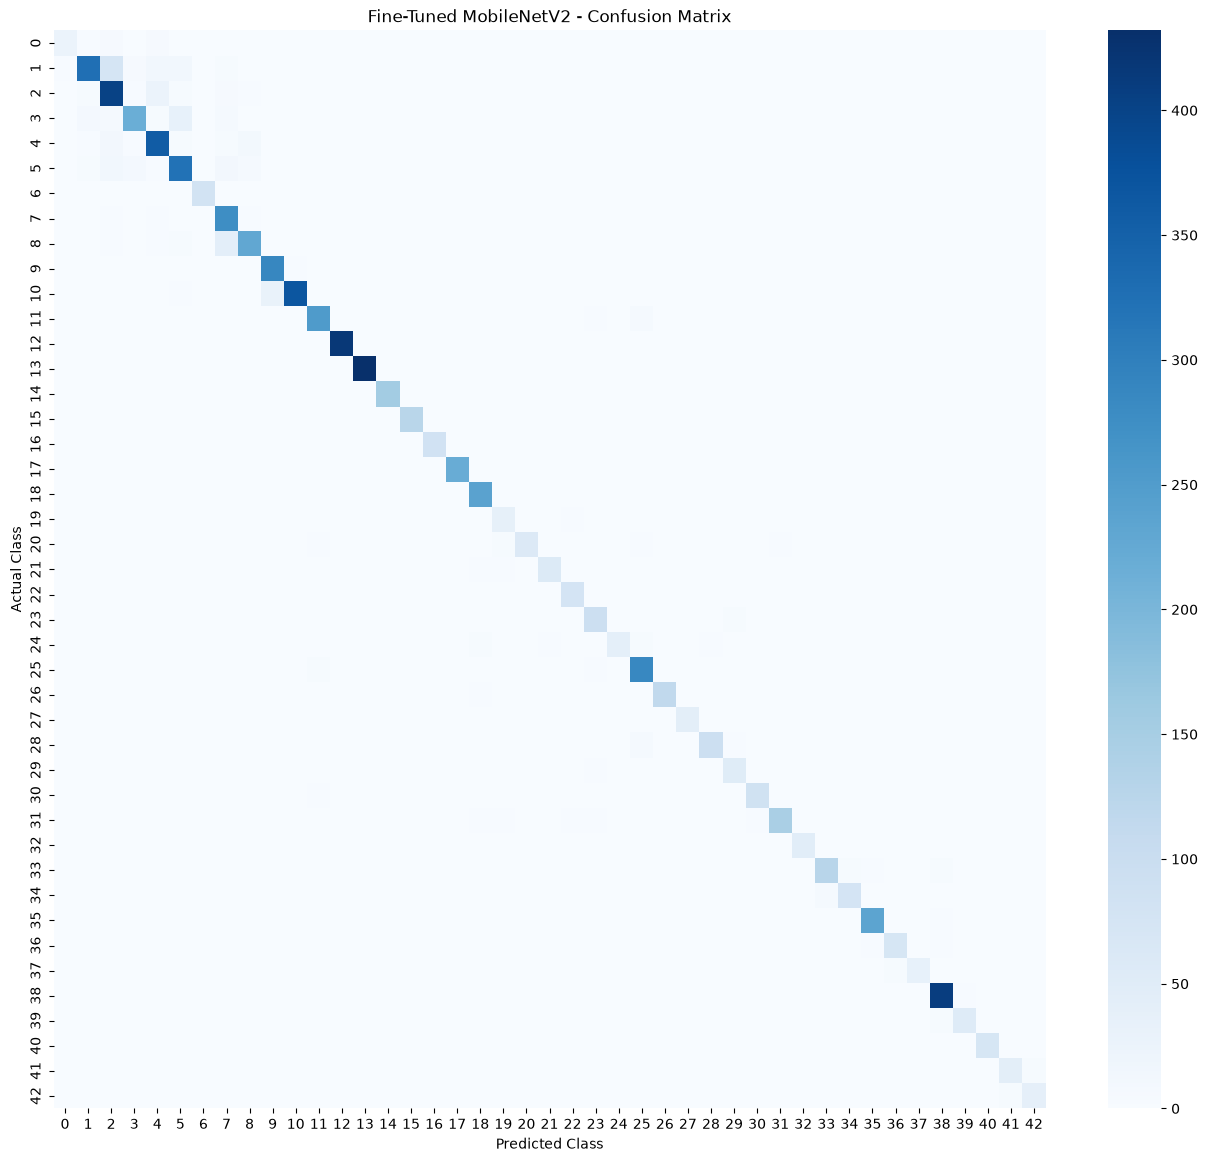

In [26]:
cm_ft = confusion_matrix(y_true_ft,y_pred_ft, labels=np.arange(NUM_CLASSES))
plt.figure(figsize=(16, 14))
sns.heatmap(cm_ft,cmap="Blues",annot=False,fmt="d")
plt.title("Fine-Tuned MobileNetV2 - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [27]:
class_f1_ft = f1_score(y_true_ft,y_pred_ft,average=None)
class_f1_ft_df = pd.DataFrame({"Class": range(NUM_CLASSES),"F1 Score": class_f1_ft}).sort_values("F1 Score")
print("Worst 10 classes:")
print(class_f1_ft_df.head(10))

Worst 10 classes:
    Class  F1 Score
0       0  0.742857
1       1  0.819095
2       2  0.827515
3       3  0.829175
19     19  0.835165
24     24  0.836735
5       5  0.847368
8       8  0.856075
7       7  0.857143
42     42  0.869565


### Model saving

In [29]:
transfer_model.save(r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\models.keras")

In [30]:
import os

print(os.path.exists(r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\model\model2.keras"))

True


In [31]:
test_items = os.listdir(os.path.join(DATA_DIR, "Test"))
print("Number of items:", len(test_items))
print(test_items[:20])

Number of items: 12631
['00000.png', '00001.png', '00002.png', '00003.png', '00004.png', '00005.png', '00006.png', '00007.png', '00008.png', '00009.png', '00010.png', '00011.png', '00012.png', '00013.png', '00014.png', '00015.png', '00016.png', '00017.png', '00018.png', '00019.png']


In [32]:
import os

DATA_DIR = r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\Data"
print(os.listdir(DATA_DIR))

['Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']


In [35]:
import pandas as pd
TEST_META = os.path.join(DATA_DIR, "Test.csv")
test_meta = pd.read_csv(TEST_META)
print(test_meta.head())
print("\nColumns:")
print(test_meta.columns)
print("\nShape:")
print(test_meta.shape)

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png

Columns:
Index(['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId',
       'Path'],
      dtype='str')

Shape:
(12630, 8)


In [36]:
print(test_meta.head(10))
print(test_meta.columns.tolist())

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png
5     52      56       5       5      47      51       38  Test/00005.png
6    147     130      12      12     135     119       18  Test/00006.png
7     32      33       5       5      26      28       12  Test/00007.png
8     45      50       6       5      40      45       25  Test/00008.png
9     81      86       7       7      74      79       35  Test/00009.png
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']


### Build the test dataframe

In [37]:
TEST_DIR = os.path.join(DATA_DIR, "Test")
test_df = test_meta.copy()
test_df["filepath"] = test_df["Path"].apply(lambda x: os.path.join(DATA_DIR, x.replace("/", os.sep)))
test_df["label"] = test_df["ClassId"].astype(int)
print("Test images:", len(test_df))
print("Test classes:", test_df["label"].nunique())
print(test_df[["filepath", "label"]].head())

Test images: 12630
Test classes: 43
                                            filepath  label
0  C:\Users\hp\OneDrive\Desktop\DeepVision-Traffi...     16
1  C:\Users\hp\OneDrive\Desktop\DeepVision-Traffi...      1
2  C:\Users\hp\OneDrive\Desktop\DeepVision-Traffi...     38
3  C:\Users\hp\OneDrive\Desktop\DeepVision-Traffi...     33
4  C:\Users\hp\OneDrive\Desktop\DeepVision-Traffi...     11


In [38]:
missing_files = test_df[~test_df["filepath"].apply(os.path.exists)]
print("Missing files:", len(missing_files))

Missing files: 0


In [39]:
test_distribution = (test_df["label"].value_counts().sort_index())
print(test_distribution)

label
0      60
1     720
2     750
3     450
4     660
5     630
6     150
7     450
8     450
9     480
10    660
11    420
12    690
13    720
14    270
15    210
16    150
17    360
18    390
19     60
20     90
21     90
22    120
23    150
24     90
25    480
26    180
27     60
28    150
29     90
30    150
31    270
32     60
33    210
34    120
35    390
36    120
37     60
38    690
39     90
40     90
41     60
42     90
Name: count, dtype: int64


In [40]:
print("Number of classes:", len(test_distribution))
print("Minimum samples in a class:", test_distribution.min())
print("Maximum samples in a class:", test_distribution.max())

Number of classes: 43
Minimum samples in a class: 60
Maximum samples in a class: 750


### Creating the test image loader

In [41]:
def load_test_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image,channels=3,expand_animations=False)
    image = tf.image.resize(image,IMG_SIZE)
    image = tf.cast(image,tf.float32)
    return image, label

### Creating the Test Dataset

In [42]:
test_ds = tf.data.Dataset.from_tensor_slices((test_df["filepath"].values,test_df["label"].values))
test_ds = test_ds.map(load_test_image,num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [43]:
for images, labels in test_ds.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Pixel minimum:", tf.reduce_min(images).numpy())
    print("Pixel maximum:", tf.reduce_max(images).numpy())

Image shape: (32, 96, 96, 3)
Label shape: (32,)
Pixel minimum: 0.08071232
Pixel maximum: 255.0


### Verifying all test labels

In [44]:
test_labels = []
for _, labels in test_ds:
    test_labels.extend(labels.numpy())
test_labels = np.array(test_labels)
print("Total test labels:", len(test_labels))
print("Unique test classes:", len(np.unique(test_labels)))
print("Classes:", np.unique(test_labels))

Total test labels: 12630
Unique test classes: 43
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


### Evaluating the fine-tuned MobileNetV2

In [45]:
test_loss, test_accuracy = transfer_model.evaluate(test_ds,verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 44s 111ms/step - accuracy: 0.7751 - loss: 0.7867
Test Loss: 0.7867
Test Accuracy: 0.7751


### Generating predictions

In [46]:
y_true_test = []
y_pred_test = []
for images, labels in test_ds:
    predictions = transfer_model.predict(images,verbose=0)
    y_true_test.extend(labels.numpy())
    y_pred_test.extend(np.argmax(predictions, axis=1))
y_true_test = np.array(y_true_test)
y_pred_test = np.array(y_pred_test)
print("True labels:", len(y_true_test))
print("Predictions:", len(y_pred_test))

True labels: 12630
Predictions: 12630


In [47]:
test_report = classification_report(y_true_test,y_pred_test,labels=np.arange(NUM_CLASSES),
    target_names=[str(i) for i in range(NUM_CLASSES)],
    digits=4,
    zero_division=0)
print(test_report)

              precision    recall  f1-score   support

           0     0.0588    0.0167    0.0260        60
           1     0.7701    0.6653    0.7139       720
           2     0.5432    0.7373    0.6256       750
           3     0.6915    0.4533    0.5477       450
           4     0.7994    0.7485    0.7731       660
           5     0.6839    0.6730    0.6784       630
           6     0.9466    0.8267    0.8826       150
           7     0.6599    0.8711    0.7510       450
           8     0.7063    0.6733    0.6894       450
           9     0.8661    0.9167    0.8907       480
          10     0.8977    0.8773    0.8874       660
          11     0.7321    0.8262    0.7763       420
          12     0.9672    0.8986    0.9316       690
          13     0.9153    0.9903    0.9513       720
          14     0.9537    0.9926    0.9728       270
          15     0.9905    0.9905    0.9905       210
          16     0.9624    0.8533    0.9046       150
          17     0.9939    

In [48]:
test_macro_f1 = f1_score(y_true_test,y_pred_test,average="macro")
test_weighted_f1 = f1_score(y_true_test,y_pred_test,average="weighted")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print(f"Test Weighted F1: {test_weighted_f1:.4f}")

Test Macro F1: 0.6970
Test Weighted F1: 0.7709


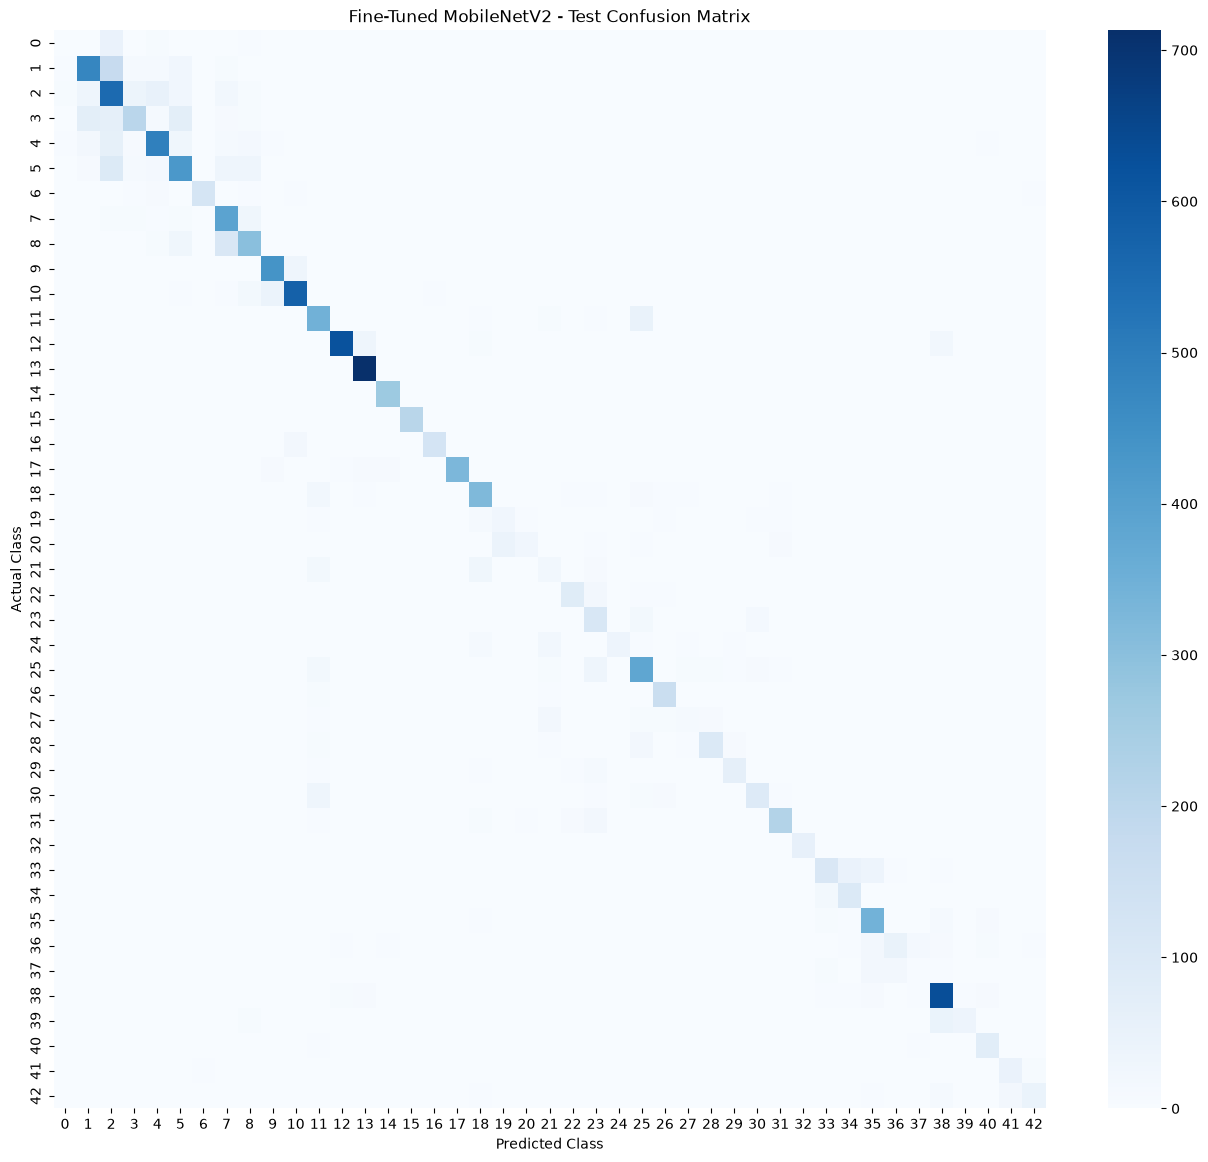

In [49]:
cm_test = confusion_matrix(y_true_test,y_pred_test,labels=np.arange(NUM_CLASSES))
plt.figure(figsize=(16, 14))
sns.heatmap(cm_test,cmap="Blues",annot=False,fmt="d")
plt.title("Fine-Tuned MobileNetV2 - Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

### CNN testing

In [51]:
cnn_model = tf.keras.models.load_model(r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\model\model1.keras")
print("CNN loaded successfully")

CNN loaded successfully


In [52]:
CNN_IMG_SIZE = (64, 64)
def load_cnn_test_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image,channels=3,expand_animations=False)
    image = tf.image.resize(image,CNN_IMG_SIZE)
    image = tf.cast(image,tf.float32) / 255.0
    return image, label

In [53]:
cnn_test_ds = tf.data.Dataset.from_tensor_slices((test_df["filepath"].values,test_df["label"].values))
cnn_test_ds = cnn_test_ds.map(load_cnn_test_image,num_parallel_calls=tf.data.AUTOTUNE)
cnn_test_ds = cnn_test_ds.batch(BATCH_SIZE)
cnn_test_ds = cnn_test_ds.prefetch(tf.data.AUTOTUNE)

In [54]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(cnn_test_ds,verbose=1)
print(f"CNN Test Loss: {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9514 - loss: 0.2117
CNN Test Loss: 0.2117
CNN Test Accuracy: 0.9514


In [55]:
y_true_cnn = []
y_pred_cnn = []
for images, labels in cnn_test_ds:
    predictions = cnn_model.predict(images,verbose=0)
    y_true_cnn.extend(labels.numpy())
    y_pred_cnn.extend(np.argmax(predictions, axis=1))
y_true_cnn = np.array(y_true_cnn)
y_pred_cnn = np.array(y_pred_cnn)

In [56]:
cnn_test_macro_f1 = f1_score(y_true_cnn,y_pred_cnn,average="macro")
cnn_test_weighted_f1 = f1_score(y_true_cnn,y_pred_cnn,average="weighted")
print(f"CNN Test Macro F1: {cnn_test_macro_f1:.4f}")
print(f"CNN Test Weighted F1: {cnn_test_weighted_f1:.4f}")

CNN Test Macro F1: 0.9266
CNN Test Weighted F1: 0.9504
